# Results

In [1]:
from sim_pipeline import *
from plot_helpers import *

import numpy as np

In [4]:

graph_kind = "rrg" # or er
lambdas=[0.3]
T_max = 10
N=6
d=3
deltas= [0.2]
rho_list = np.arange(0, 1.1, 0.1)
#rho_list = [0.3, 0.6]
Nsim = 10

param_list = [(delta, lam, rho) for delta in deltas for lam in lambdas for rho in rho_list]
# sensor selection method

methods = ["random", "page_rank", "betweenness", "degree"] # ["random", "greedyOV", "greedySampleReplaceOV"] # ["random", "betweenness"] # ["random", "greedyOV"] #["random", "page_rank", "betweenness", "degree"] # greedyOV, greedyMOV, random, RL...
params = {"N": N, "d": d, "T_max": T_max, "Nsim": Nsim, "methods": methods, "param_list": param_list, "graph_kind": graph_kind}

## Run new simulation

In [5]:
results_df = full_sim(params, Gfixed=False)

Running method random...


Simulations: 100%|██████████| 11/11 [00:02<00:00,  4.99it/s]


Running method page_rank...


Simulations: 100%|██████████| 11/11 [00:02<00:00,  4.55it/s]


Running method betweenness...


Simulations: 100%|██████████| 11/11 [00:02<00:00,  4.84it/s]


Running method degree...


Simulations: 100%|██████████| 11/11 [00:02<00:00,  4.89it/s]


Results saved to results/methods_random_page_rank_betweenness_degree_N6_d3_T10_Nsim10.csv


## Load previous simulation results

In [5]:
PATH = "./results/methods_random_page_rank_betweenness_degree_N100_d3_T10_Nsim10.csv"
results_df = pd.read_csv(PATH)

In [22]:
random_results_df = results_df[results_df["method"] == "random"]
pagerank_results_df = results_df[results_df["method"] == "page_rank"]
betweenness_results_df = results_df[results_df["method"] == "betweenness"]
degree_results_df = results_df[results_df["method"] == "degree"]
greedyOV_results_df = results_df[results_df["method"] == "greedyOV"]

/Users/marzioformica/Desktop/EPFL/Master/MinorDS/ProjectSPOC/bpepi/SensorSelection/plot_helpers.py:23: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=selected_results, x="rho", y=metric, hue="delta", palette="Set2", ax=axes[1])
/Users/marzioformica/Desktop/EPFL/Master/MinorDS/ProjectSPOC/bpepi/SensorSelection/plot_helpers.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(title="$\\delta$", loc="upper left")


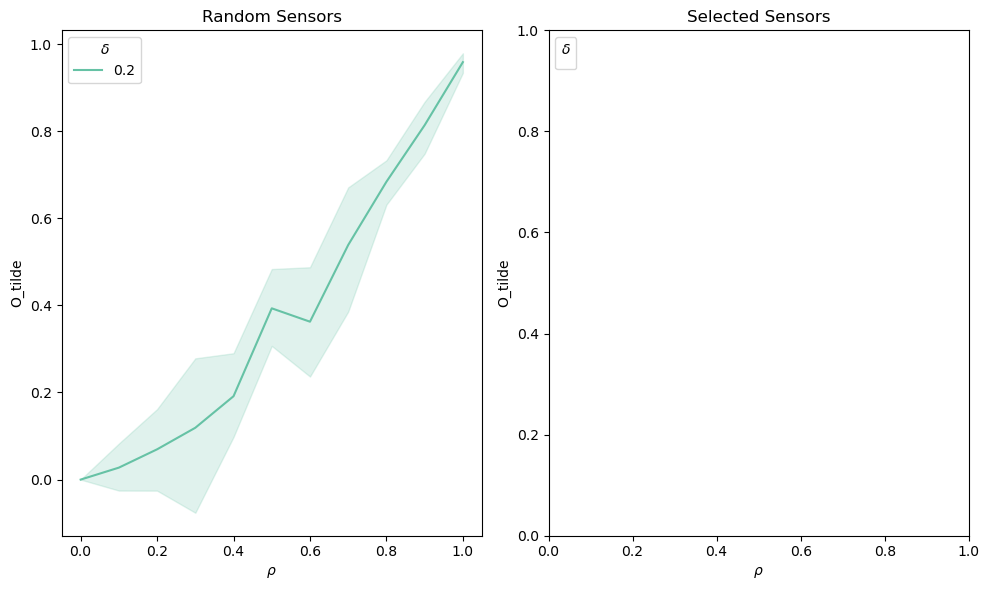

In [23]:
plot_side_by_side(random_results_df, greedyOV_results_df, metric="O_tilde")

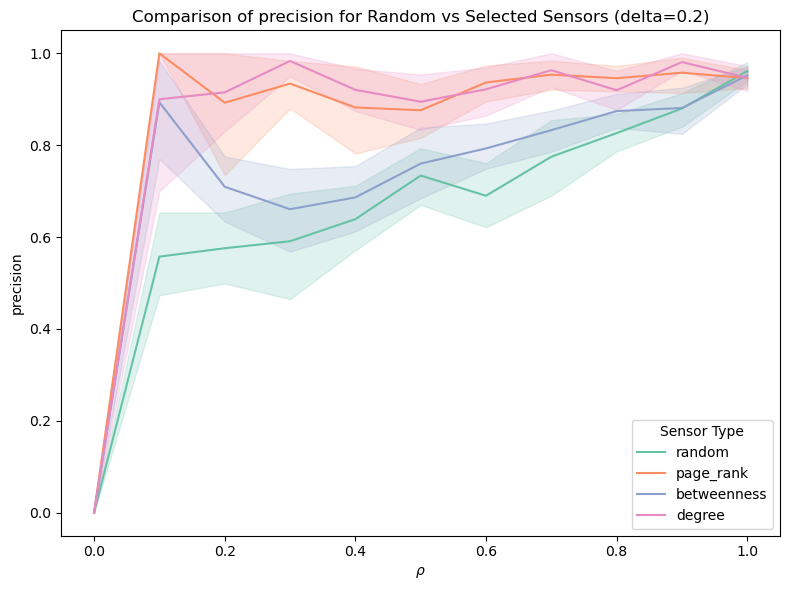

In [25]:
plot_comparison(results_df, delta=deltas[0], metric="precision")